In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [160]:
import matplotlib.font_manager as fm

# 맥 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [161]:
import pandas as pd

# 1. 행(rows) 제한 없애기
pd.set_option('display.max_rows', None)

# 2. 열(columns) 제한 없애기
pd.set_option('display.max_columns', None)

# 3. 각 열의 너비 제한 없애기 (내용이 길 때 잘리는 것 방지)
pd.set_option('display.max_colwidth', None)

# 4. 출력 너비 설정 (줄바꿈 방지)
pd.set_option('display.width', None)


# ===============

In [162]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 배송일이 2099-01-01인 더미 데이터 제거 
# == delivered -> 실제로 배송 완료된 주문만 남김 
df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]

In [163]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_payment_value,review_id,review_score,review_creation_date,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,2017-12-03,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,e50934924e227544ba8246aeb3770dd4,5.0,2018-02-17,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery


In [ ]:
# 배송 지연 일수 계산

# 실제 배송일 - 예정 배송일 = 지연 일수 
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['actual_delay_days'] = np.where(df['delivery_delay_days'] < 0 , 0, df['delivery_delay_days'])

# 양수면 지연 1, 0이하면 정상 
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

현재 0(정시 배송)이 약 10만 건
1~100일(지연)은 다 합쳐도 약 7,300건 정도
 (비율이 거의 14:1)

이렇게 데이터가 한쪽으로 심하게 쏠려 있을 때(Imbalanced Data), 0을 무작정 다 쓰면 모델이 **"그냥 0이라고 답하면 93%는 맞네?"**라고 생각할 수 있음 

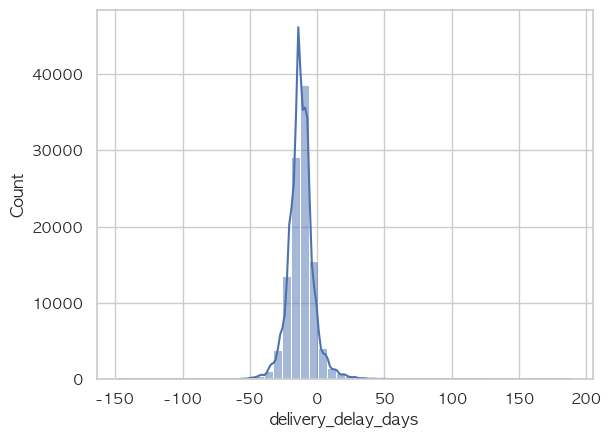

In [165]:
sns.histplot(df['delivery_delay_days'], bins=50, kde=True)
plt.show()

In [166]:
df.shape

(109614, 32)

In [167]:
df = df[df['delivery_delay_days'] <= 100]
print(df.shape)
print(df['delivery_delay_days'].max())

(109571, 32)
100


In [168]:
df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
total_payment_value                     float64
review_id                                   str
review_score                            float64
review_creation_date             datetim

# 구매 기간과 배송지연의 관계

In [169]:
# 분기(Quarter) 추출 (예: Q1, Q2, Q3, Q4)
df['purchase_quarter'] = df['order_purchase_timestamp'].dt.quarter
# 요일 추출 (0=월, 6=일)
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek


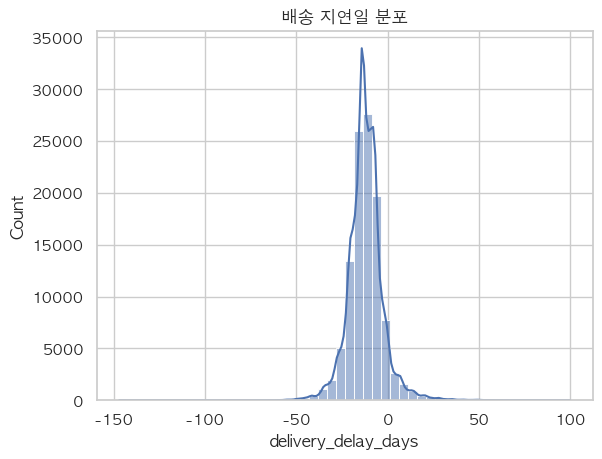

왜도: 0.6724448078623771
첨도: 8.60198849897206


In [170]:
sns.histplot(df['delivery_delay_days'], bins=50, kde=True)
plt.title('배송 지연일 분포')
plt.xlabel('delivery_delay_days')
plt.show()

print('왜도:', df['delivery_delay_days'].skew())
print('첨도:', df['delivery_delay_days'].kurt())

- 왜도가 0보다 큰 약 2.8이기에 양수(왼쪽)으로 치우치고 오른쪽으로 긴 꼬리가 있는 모양
- 첨도가 약 12.66으로 크기 때문에 분포가 중양에 아주 뾰족하게 솟아있고, 동시에 꼬리가 아주 두껍다


-> 우리는 꼬리 부분에 해당하는 주문들을 미리 감지하고 관리하는 것이 고객 만족도 방어에 효과적일 것이라고 판단

In [171]:
# 검정 방법을 결정하기 위해 정규성 검정 
# 그래프로도 알 수 있지만 한번 더 확인 + 복습 겸 
stat, p = stats.shapiro(df['delivery_delay_days'].sample(5000, random_state=42))
print(f'p-value: {p:.4f}')
print('정규분포 O → ANOVA' if p >= 0.05 else '정규분포 X → Kruskal-Wallis')

p-value: 0.0000
정규분포 X → Kruskal-Wallis


Shapiro-Wilk 검정 ($p < 0.05$): 귀무가설(정규분포를 따른다)을 기각

즉, 이 데이터는 통계적으로 "정규분포가 아니다

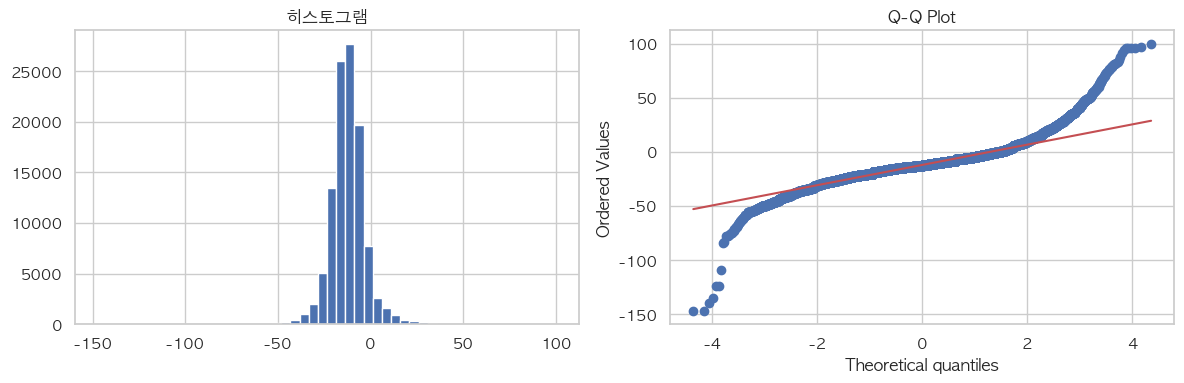

In [172]:
# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['delivery_delay_days'], bins=50)
axes[0].set_title('히스토그램')
stats.probplot(df['delivery_delay_days'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

- 그래프에서 점들이 직선(대각선) 위에 있지 않고, 양 끝이 위로 확 솟아오른 모양

- 오른쪽으로 매우 긴 꼬리(Heavy-tail)를 가지고 있다는 시각적 증거

### 통계 검정 - 분기별 

In [173]:
# 통계 검정 - 분기별 

# 귀무가설 : 차이가 없다 (분기별 배송 지연일의 분포는 모두 같다)
# 대립가설: 최소한 한 그룹은 차이가 있다

groups = [df[df['purchase_quarter'] == q]['delivery_delay_days'].dropna() for q in [1,2,3,4]]

stat, p = stats.kruskal(*groups)
print(f'p-value: {p:.4f}')
print('분기별 차이 유의미' if p < 0.05 else '분기별 차이 없음')

p-value: 0.0000
분기별 차이 유의미


- 대립가설 채택 -> 분기별 배송 지연의 차이가 운에 의한 것이 아닌 특정 분기마다 물류 환경이 변화고 있음을 나타낸다

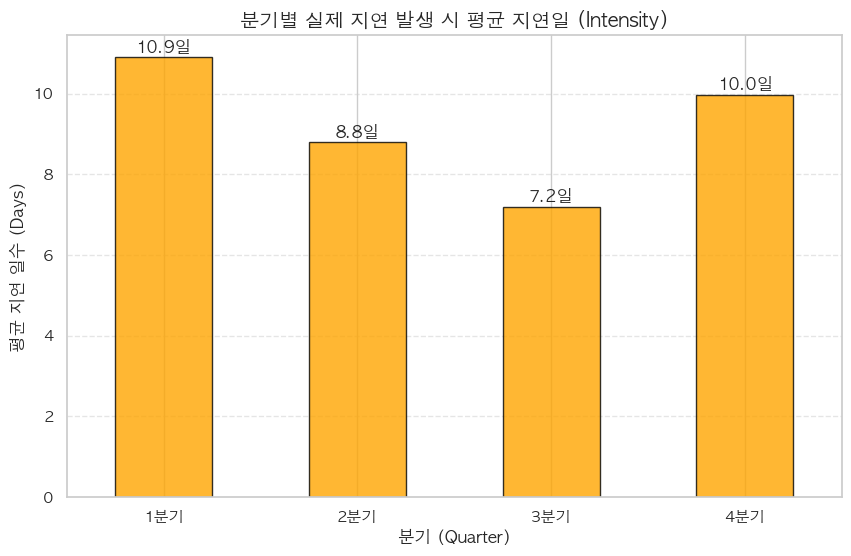

In [ ]:
# 지연이 발생한(양수인) 데이터만 필터링
df_only_delayed = df[df['delivery_delay_days'] > 0]

# 분기별 평균 계산 및 시각화
plt.figure(figsize=(10, 6))
df_only_delayed.groupby('purchase_quarter')['delivery_delay_days'].mean().plot(
    kind='bar', 
    color='orange', 
    edgecolor='black',
    alpha=0.8
)

plt.title('분기별 실제 지연 발생 시 평균 지연일 (Intensity)', fontsize=14, fontweight='bold')
plt.xlabel('분기 (Quarter)', fontsize=12)
plt.ylabel('평균 지연 일수 (Days)', fontsize=12)
plt.xticks(ticks=[0,1,2,3], labels=['1분기','2분기','3분기','4분기'], rotation=0)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}일', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1705205861.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchase_quarter', y='delivery_delay_days', data=df, palette='Set3')


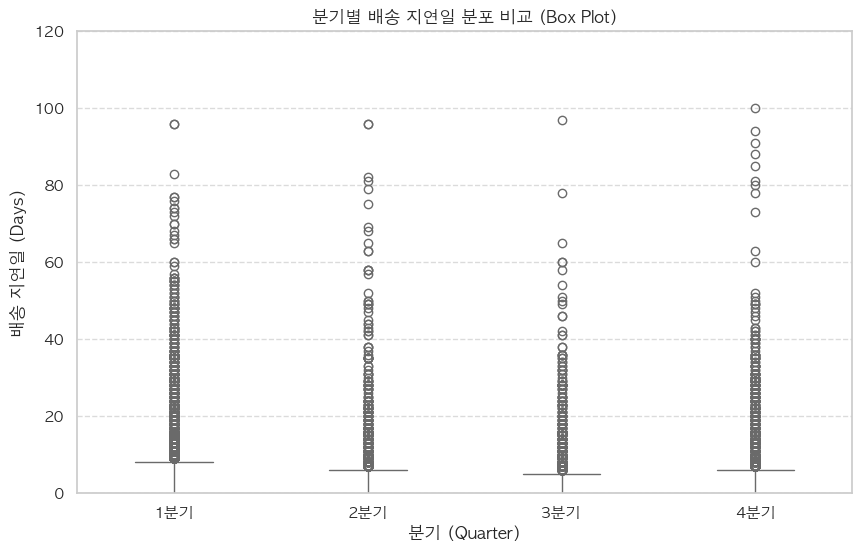

In [ ]:
plt.figure(figsize=(10, 6))

# 박스 플롯 그리기
sns.boxplot(x='purchase_quarter', y='delivery_delay_days', data=df, palette='Set3')

plt.title('분기별 배송 지연일 분포 비교 (Box Plot)')
plt.xlabel('분기 (Quarter)')
plt.ylabel('배송 지연일 (Days)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['1분기', '2분기', '3분기', '4분기'])

plt.ylim(0, 120) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [177]:
df['purchase_quarter'].value_counts()

purchase_quarter
2    32544
1    29177
3    27673
4    20177
Name: count, dtype: int64

In [178]:
from scipy import stats
from itertools import combinations

# 귀무가설: 비교하는 두 분기 간의 배송 지연일 분포는 차이가 없다
# 대립가설: 비교하는 두 분기 간의 배송 지연일 분포는 통계적으로 유의미하게 다르다


quarters = [1, 2, 3, 4]
pairs = list(combinations(quarters, 2))

print('=== Dunn Test (Bonferroni 보정) ===')
n_tests = len(pairs)

for q1, q2 in pairs:
    g1 = df[df['purchase_quarter'] == q1]['delivery_delay_days'].dropna()
    g2 = df[df['purchase_quarter'] == q2]['delivery_delay_days'].dropna()
    
    stat, p = stats.mannwhitneyu(g1, g2)
    p_bonferroni = min(p * n_tests, 1.0)  # Bonferroni 보정
    
    sig = '유의미' if p_bonferroni < 0.05 else '유의미하지 않음'
    print(f'{q1}분기 vs {q2}분기 | p(보정후)={p_bonferroni:.4f} | {sig}')

=== Dunn Test (Bonferroni 보정) ===
1분기 vs 2분기 | p(보정후)=0.0000 | 유의미
1분기 vs 3분기 | p(보정후)=0.0000 | 유의미
1분기 vs 4분기 | p(보정후)=1.0000 | 유의미하지 않음
2분기 vs 3분기 | p(보정후)=0.0000 | 유의미
2분기 vs 4분기 | p(보정후)=0.0000 | 유의미
3분기 vs 4분기 | p(보정후)=0.0000 | 유의미


In [ ]:
# Kruskal-Wallis 검정 수행
kw_stat, kw_p = stats.kruskal(*groups)

N = len(df['delivery_delay_days'].dropna()) # 전체 데이터 개수 (결측치 제외)
k = df['purchase_quarter'].nunique()        # 그룹 수 (분기니까 4)

# 효과 크기(Eta-squared) 계산
eta_sq = (kw_stat - k + 1) / (N - k)

print(f"Kruskal-Wallis H-statistic: {kw_stat:.4f}")
print(f"Effect Size (Eta-squared): {eta_sq:.4f}")

# 효과 크기 해석 기준 
if eta_sq < 0.01:
    interpretation = "매우 작음 (Negligible)"
elif eta_sq < 0.06:
    interpretation = "작음 (Small)"
elif eta_sq < 0.14:
    interpretation = "중간 (Medium)"
else:
    interpretation = "큼 (Large)"

print(f"효과 크기 해석: {interpretation}")

Kruskal-Wallis H-statistic: 3031.3738
Effect Size (Eta-squared): 0.0276
효과 크기 해석: 작음 (Small)


- 1분기(1~3월) 에 지연 건수(3,153건)와 평균 지연일(10.9일)이 가장 높게 나타났음

=====================
- 검증 결과: Kruskal-Wallis 및 사후 분석(Dunn's Test) 결과, 모든 분기 간 배송 지연 분포의 차이가 통계적으로 유의미($p < 0.05$)함을 확인

- 의미: 배송 지연은 무작위로 발생하는 것이 아니라, 분기(시즌성) 요소에 따라 물류 부하가 달라지며 발생
    - 따라서 이 요소들은 지연을 예측하는 데 결정적인 피처가 될 수 있다

# 클래스 불균형 - 0일에 비율 고민

In [180]:
print(df['is_delayed'].value_counts())
print(df['is_delayed'].value_counts(normalize= True))

is_delayed
0    102359
1      7212
Name: count, dtype: int64
is_delayed
0    0.93418
1    0.06582
Name: proportion, dtype: float64


0이 너무 많으면 모델이 0에 고정이 될 우려가 있음
 - 0이 약 10만건, 1~100일이 약 7000건 
 - 0이 93% 인 상태에서 모델을 돌리면, 모델이 무조건 0이라고만 답해도 정확도가 93%가 나옴. 
 - 특정 조건에서 지연 일수를 좀 더 예민하게 관찰하기 위해 
 - 0의 비율을 무작위 추출을 통해 줄인다


 ### 그렇다면 비율은 어떻게 해야할까? 
 - 1:1로 하면 0의 데이터가 실제 데이터에 비해 너무 적어진다
    - 현실적으로 정상 데이터가 더 많다는 사실을 모델에게 어느 정도 인지시켠서, 학습이 한쪽으로 쏠리는 것을 막을 수 있도록
- 1:2과 1:3 비율로 샘플링하여 효과크기를 살펴본다


분석 시작: 샘플링 비율 1:2
1. Kruskal-Wallis 검정 결과
   - [분기] p-value: 4.8601e-267 | Eta-sq: 0.0569
   - [요일] p-value: 9.0660e-02 | Eta-sq: 0.0002

2. 사후검정 결과 (Significant Pair Counts)
   - 유의미한 분기 쌍: 5 / 6
   - 유의미한 요일 쌍: 0 / 21


/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchase_quarter', y='actual_delay_days', data=df_positive, ax=axes[0], palette='Set3')
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='purchase_day_of_week', y='actual_delay_days', data=df_positive,
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(day_names)


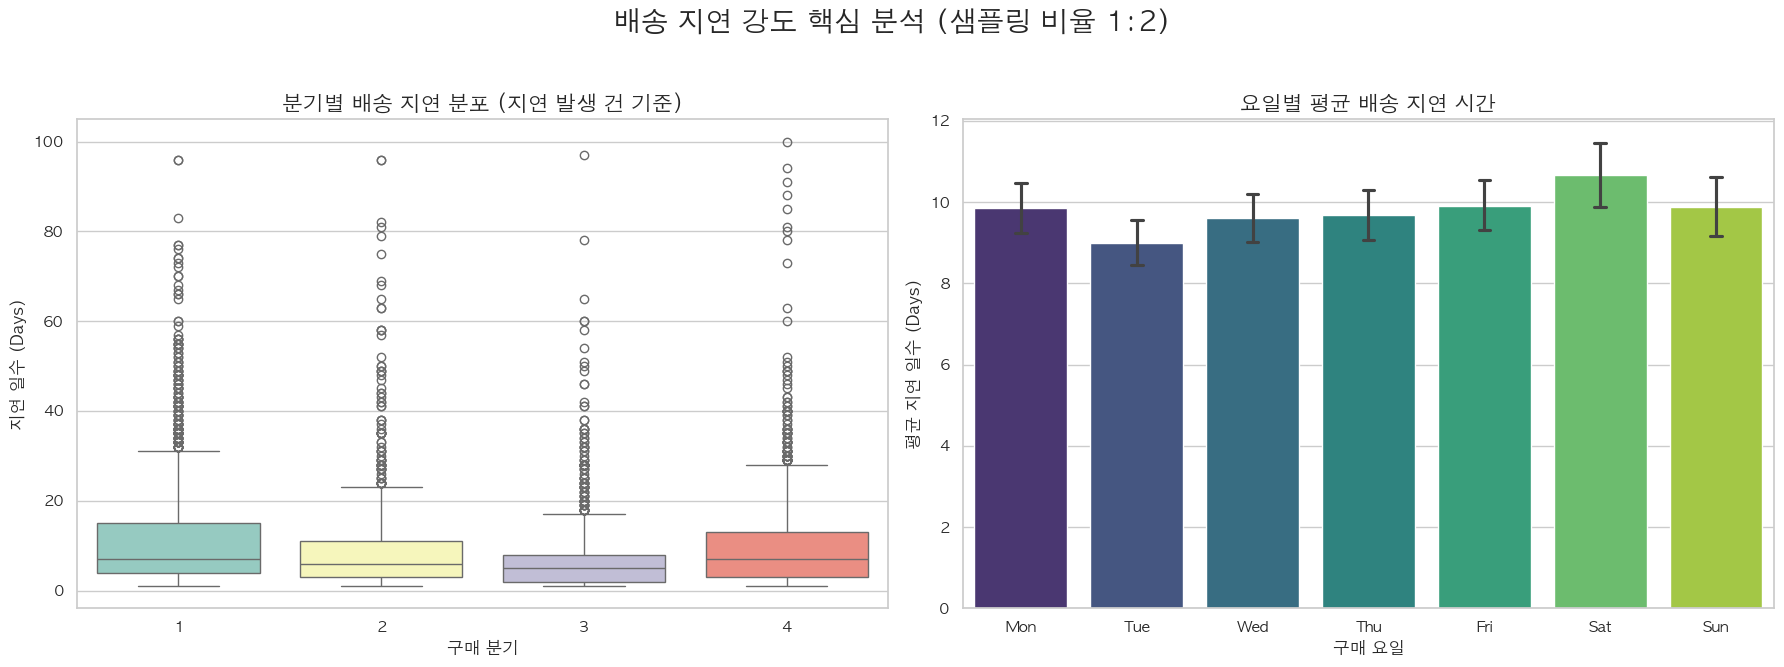


분석 시작: 샘플링 비율 1:3
1. Kruskal-Wallis 검정 결과
   - [분기] p-value: 2.0526e-291 | Eta-sq: 0.0465
   - [요일] p-value: 1.6802e-02 | Eta-sq: 0.0003

2. 사후검정 결과 (Significant Pair Counts)
   - 유의미한 분기 쌍: 5 / 6
   - 유의미한 요일 쌍: 1 / 21


/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchase_quarter', y='actual_delay_days', data=df_positive, ax=axes[0], palette='Set3')
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='purchase_day_of_week', y='actual_delay_days', data=df_positive,
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_51714/1096815823.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(day_names)


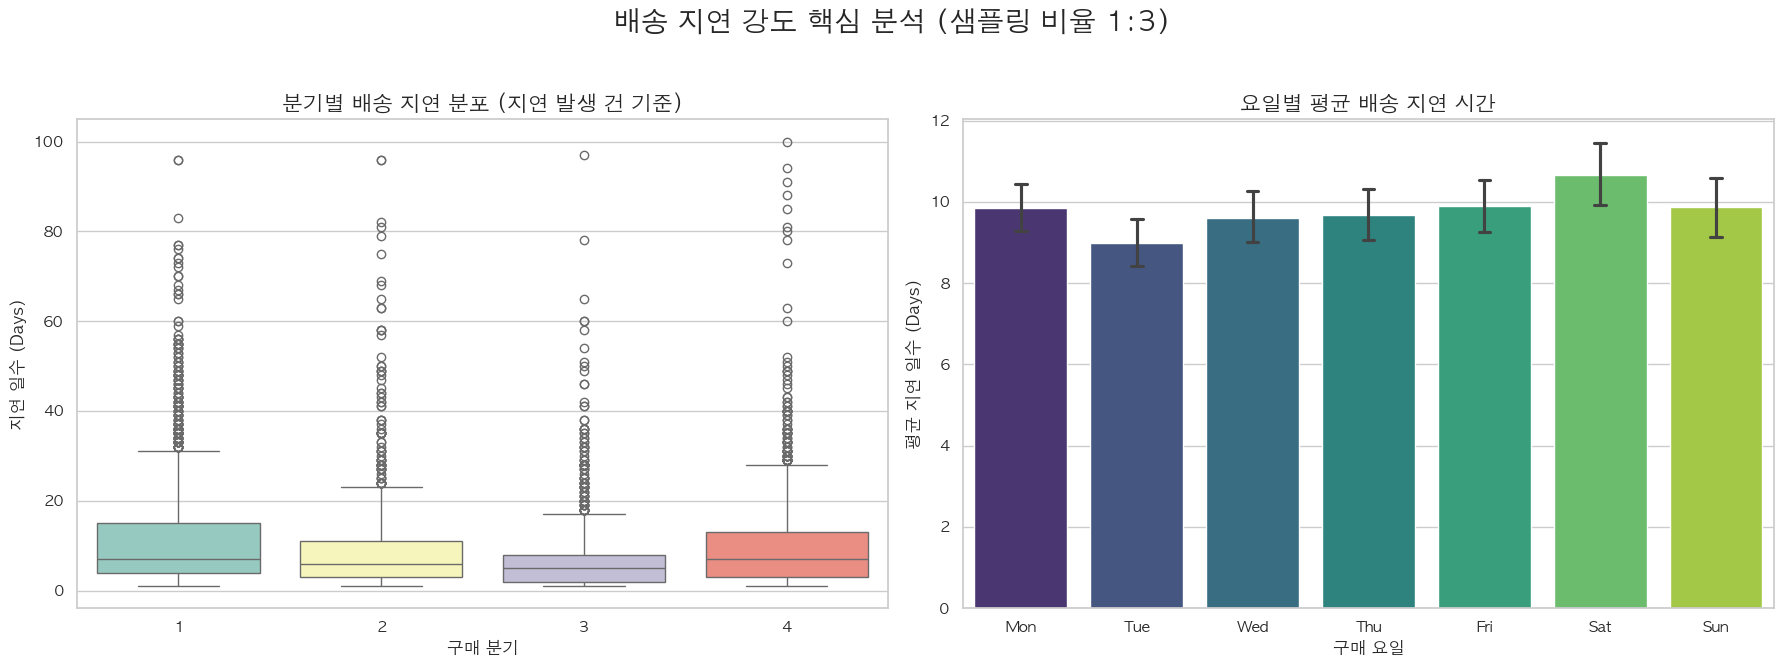


### 분석 파이프라인 최종 요약 보고서 ###
  Ratio  Q_Eta_sq  D_Eta_sq  Sig_Quarter_Pairs  Sig_Day_Pairs
0   1:2  0.056864  0.000228                  5              0
1   1:3  0.046541  0.000329                  5              1


In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

# --- 1. 환경 설정 ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False 

def plot_visuals(df_sample, ratio_label, day_names):
    """지연 강도 분석을 위한 핵심 차트 시각화"""
    # 실제 지연이 발생한 건(양수)만 필터링하여 '강도' 집중 분석
    df_positive = df_sample[df_sample['actual_delay_days'] > 0].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'배송 지연 강도 핵심 분석 (샘플링 비율 {ratio_label})', fontsize=20, fontweight='bold')

    # (1) 분기별 지연 일수 분포 (Box Plot)
    sns.boxplot(x='purchase_quarter', y='actual_delay_days', data=df_positive, ax=axes[0], palette='Set3')
    axes[0].set_title('분기별 배송 지연 분포 (지연 발생 건 기준)', fontsize=15)
    axes[0].set_xlabel('구매 분기', fontsize=12)
    axes[0].set_ylabel('지연 일수 (Days)', fontsize=12)

    # (2) 요일별 평균 지연 일수 (Bar Plot)
    day_order = [0, 1, 2, 3, 4, 5, 6]
    sns.barplot(x='purchase_day_of_week', y='actual_delay_days', data=df_positive, 
                ax=axes[1], order=day_order, palette='viridis', capsize=.1)
    axes[1].set_xticklabels(day_names)
    axes[1].set_title('요일별 평균 배송 지연 시간', fontsize=15)
    axes[1].set_xlabel('구매 요일', fontsize=12)
    axes[1].set_ylabel('평균 지연 일수 (Days)', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def run_comprehensive_analysis(df_input):
    """통계 검정과 시각화를 통합 실행"""
    results_list = []
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    for r in [2, 3]:
        ratio_label = f"1:{r}"
        print(f"\n{'='*40}")
        print(f"분석 시작: 샘플링 비율 {ratio_label}")
        print(f"{'='*40}")

        # [1] 데이터 샘플링
        df_delayed = df_input[df_input['actual_delay_days'] > 0]
        df_zero = df_input[df_input['actual_delay_days'] == 0]
        df_zero_sampled = df_zero.sample(n=len(df_delayed) * r, random_state=42)
        df_sample = pd.concat([df_delayed, df_zero_sampled])
        
        # [2] 통계 검정 (Kruskal-Wallis)
        # 지연 여부와 상관없이 샘플 전체에서의 차이를 확인
        quarters = sorted(df_sample['purchase_quarter'].unique())
        groups_q = [df_sample[df_sample['purchase_quarter'] == q]['actual_delay_days'] for q in quarters]
        h_q, p_kw_q = stats.kruskal(*groups_q)
        eta_sq_q = (h_q - len(quarters) + 1) / (len(df_sample) - len(quarters))
        
        days = sorted(df_sample['purchase_day_of_week'].unique())
        groups_d = [df_sample[df_sample['purchase_day_of_week'] == d]['actual_delay_days'] for d in days]
        h_d, p_kw_d = stats.kruskal(*groups_d)
        eta_sq_d = (h_d - len(days) + 1) / (len(df_sample) - len(days))
        
        print(f"1. Kruskal-Wallis 검정 결과")
        print(f"   - [분기] p-value: {p_kw_q:.4e} | Eta-sq: {eta_sq_q:.4f}")
        print(f"   - [요일] p-value: {p_kw_d:.4e} | Eta-sq: {eta_sq_d:.4f}")

        # [3] 사후검정 (Bonferroni 보정) - 개수 요약
        print(f"\n2. 사후검정 결과 (Significant Pair Counts)")
        
        # 분기 사후검정
        quarter_pairs = list(combinations(quarters, 2))
        sig_q = [p for p in quarter_pairs if min(stats.mannwhitneyu(df_sample[df_sample['purchase_quarter']==p[0]]['actual_delay_days'], 
                                                                    df_sample[df_sample['purchase_quarter']==p[1]]['actual_delay_days'])[1] * len(quarter_pairs), 1.0) < 0.05]
        
        # 요일 사후검정
        day_pairs = list(combinations(days, 2))
        sig_d = [p for p in day_pairs if min(stats.mannwhitneyu(df_sample[df_sample['purchase_day_of_week']==p[0]]['actual_delay_days'], 
                                                                df_sample[df_sample['purchase_day_of_week']==p[1]]['actual_delay_days'])[1] * len(day_pairs), 1.0) < 0.05]

        print(f"   - 유의미한 분기 쌍: {len(sig_q)} / {len(quarter_pairs)}")
        print(f"   - 유의미한 요일 쌍: {len(sig_d)} / {len(day_pairs)}")

        # [4] 시각화 실행
        plot_visuals(df_sample, ratio_label, day_names)
        
        # 결과 데이터 저장
        results_list.append({
            'Ratio': ratio_label,
            'Q_Eta_sq': eta_sq_q,
            'D_Eta_sq': eta_sq_d,
            'Sig_Quarter_Pairs': len(sig_q),
            'Sig_Day_Pairs': len(sig_d)
        })

    return pd.DataFrame(results_list)

final_analysis_report = run_comprehensive_analysis(df)

print("\n" + "### 분석 파이프라인 최종 요약 보고서 ###")
print(final_analysis_report)

### 데이터 샘플링 결과 (1:2 vs 1:3)

실제 데이터는 정시 배송(0일)이 93%에 달하는 극심한 불균형 상태임.
이를 해결하기 위해 수행한 샘플링 결과

최종 선택: 1:3 비율
이유: 1:2 비율과 통계적 유의성(상관계수, 효과크기)에서 큰 차이가 없으면서도, 학습 데이터 양을 1.3배 더 확보할 수 있어 모델의 일반화 성능(과적합 방지)에 유리
구성: 지연 데이터(1~100일) 약 7천 건 + 정상 데이터(0일) 약 2.1만 건 = 총 약 2.8만 건

# 월별 지연율 